# Thực hành Buổi 15: Graph Analytics với NetworkX & Neo4j Cypher

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** NetworkX, Neo4j (Docker), Cypher Query Language

**Đầu vào ➔ Đầu ra:** `chat_logs.csv` (nhật ký chat nội bộ) ➔ **trực quan hóa đồ thị mạng lưới + kết quả PageRank** (`data/processed/graph_mang_luoi.png`, `data/processed/pagerank_nhan_vien.csv`)

> **Vì sao cần đồ thị?** Bảng quan hệ trả lời tốt câu hỏi về **từng dòng** (doanh thu bao nhiêu, ai churn). Nhưng câu hỏi về **mối quan hệ** — *ai là trung tâm, ai là cầu nối, tin đồn lan qua ngả nào, nhóm nào chơi với nhau* — viết bằng SQL sẽ là những chuỗi JOIN đệ quy kinh hoàng. Mô hình **đồ thị** (đỉnh + cạnh) sinh ra cho đúng lớp câu hỏi đó.

| Phần | Câu hỏi | Công cụ |
|:---|:---|:---|
| 15.1 | Bảng quan hệ ➔ đồ thị như thế nào? | Pandas ➔ NetworkX |
| 15.2 | Mạng lưới trông ra sao? | vẽ đồ thị (deliverable 1) |
| 15.3 | Ai quan trọng — theo nghĩa NÀO? | Degree / Betweenness / Closeness Centrality |
| 15.4 | Ai "uy tín" nhất? | PageRank (deliverable 2) |
| 15.5 | Tổ chức "thật" có giống sơ đồ tổ chức? | Phát hiện cộng đồng (Louvain) |
| 15.6 | Truy vấn đồ thị trong CSDL chuyên dụng? | Neo4j + Cypher + GDS |

> ⚠️ **Chuẩn bị:** phần 15.6 cần Docker đang chạy (dịch vụ `neo4j` trong `docker-compose.yml` của khóa học — notebook tự bật). Các phần 15.1–15.5 chạy hoàn toàn trên máy, không cần Docker.

In [2]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


## PHẦN 0 — SINH DỮ LIỆU `chat_logs.csv`

Nhật ký 15.000 tin nhắn nội bộ trong 60 ngày của công ty 82 nhân viên (5 phòng ban × 16 người + Giám đốc + Trợ lý). Cấu trúc được **cấy chủ đích** để các thuật toán "khai quật" lại:

- Nhân viên chủ yếu nhắn **trong phòng ban mình** ➔ thuật toán cộng đồng phải tìm lại được 5 phòng;
- Mỗi phòng có một **Đầu mối** nhận tin liên phòng ➔ phải nổi lên ở Betweenness;
- **Trợ lý** nhắn khắp nơi, **Giám đốc** được mọi người nhắn tới ➔ phải nổi lên ở Degree/PageRank.

Hạt giống `seed=42` ➔ mọi máy ra kết quả giống hệt nhau.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

plt.rcParams["figure.dpi"] = 100

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("networkx", nx.__version__)

networkx 3.6.1


In [4]:
# ==== SINH chat_logs.csv (kết quả cố định nhờ seed=42) ====
rng = np.random.default_rng(42)

PHONG_BAN = ["Kinh doanh", "Kỹ thuật", "Marketing", "Tài chính", "Nhân sự"]
nhan_vien = [{"id": "E001", "phong_ban": "Ban Giám đốc", "vai_tro": "Giám đốc"},
             {"id": "E002", "phong_ban": "Ban Giám đốc", "vai_tro": "Trợ lý"}]
for p, pb in enumerate(PHONG_BAN):
    for i in range(16):
        nhan_vien.append({"id": f"E{3 + p * 16 + i:03d}", "phong_ban": pb,
                          "vai_tro": "Đầu mối" if i == 0 else "Nhân viên"})
nv = pd.DataFrame(nhan_vien)
cung_phong = {pb: nv.loc[nv["phong_ban"] == pb, "id"].tolist() for pb in PHONG_BAN}
dau_moi = {pb: cung_phong[pb][0] for pb in PHONG_BAN}
phong_cua = dict(zip(nv["id"], nv["phong_ban"]))

# Mức độ "hay chat" của từng người (Trợ lý x4, Giám đốc x2)
hoat_dong = rng.lognormal(0, 0.5, len(nv))
hoat_dong[0] *= 2; hoat_dong[1] *= 4
p_gui = hoat_dong / hoat_dong.sum()

N_TIN = 15_000
tat_ca = nv["id"].tolist()
dong = []
for i in range(N_TIN):
    gui = tat_ca[rng.choice(len(tat_ca), p=p_gui)]
    r = rng.random()
    if gui == "E001":                                   # Giám đốc nhắn khắp nơi
        nhan = tat_ca[rng.integers(1, len(tat_ca))]
    elif gui == "E002":                                 # Trợ lý: nửa cho đầu mối, nửa ngẫu nhiên
        nhan = (dau_moi[PHONG_BAN[rng.integers(5)]] if r < 0.5
                else tat_ca[rng.integers(len(tat_ca))])
    else:
        pb = phong_cua[gui]
        if r < 0.68:                                    # nội bộ phòng
            nhan = cung_phong[pb][rng.integers(16)]
        elif r < 0.80:                                  # gửi đầu mối phòng mình
            nhan = dau_moi[pb]
        elif r < 0.88:                                  # gửi Trợ lý
            nhan = "E002"
        elif r < 0.94:                                  # báo cáo Giám đốc
            nhan = "E001"
        else:                                           # liên phòng: qua đầu mối phòng khác
            nhan = dau_moi[PHONG_BAN[rng.integers(5)]]
    if nhan == gui:
        nhan = "E002" if gui != "E002" else "E001"
    dong.append((f"M{i:05d}",
                 (pd.Timestamp("2025-07-01") + pd.Timedelta(days=int(rng.integers(60)),
                  hours=int(rng.integers(8, 19)), minutes=int(rng.integers(60)))
                  ).strftime("%Y-%m-%d %H:%M"),
                 gui, nhan, int(rng.lognormal(4, 0.6))))

chat = pd.DataFrame(dong, columns=["msg_id", "ts", "sender", "receiver", "so_ky_tu"])
chat.to_csv(RAW / "chat_logs.csv", index=False)
print(f"Đã sinh chat_logs.csv: {len(chat):,} tin nhắn, {nv.shape[0]} nhân viên, "
      f"{chat['ts'].min()[:10]} -> {chat['ts'].max()[:10]}")
chat.head()

Đã sinh chat_logs.csv: 15,000 tin nhắn, 82 nhân viên, 2025-07-01 -> 2025-08-29


,msg_id,ts,sender,receiver,so_ky_tu
0,M00000,2025-08-13 15:27,E001,E064,41
1,M00001,2025-08-11 13:26,E040,E042,51
2,M00002,2025-07-22 18:05,E023,E028,24
3,M00003,2025-07-30 15:27,E079,E001,119
4,M00004,2025-07-16 16:26,E063,E051,48


---
## 15.1. Từ bảng quan hệ sang Đồ thị

Từ vựng tối thiểu:

| Khái niệm | Trong bài này |
|:---|:---|
| **Node (đỉnh)** | một nhân viên |
| **Edge (cạnh)** | "A đã nhắn tin cho B" |
| **Directed (có hướng)** | A nhắn B ≠ B nhắn A |
| **Weighted (có trọng số)** | số tin nhắn A ➔ B |

Bảng log 15.000 dòng ➔ **gộp** thành danh sách cạnh (edge list): mỗi cặp (người gửi, người nhận) một dòng, trọng số = số tin. Đó là toàn bộ phép "chuyển đổi dữ liệu quan hệ sang đồ thị".

In [5]:
canh = (chat.groupby(["sender", "receiver"])
        .agg(so_tin=("msg_id", "size"), tong_ky_tu=("so_ky_tu", "sum"))
        .reset_index())

G = nx.from_pandas_edgelist(canh, source="sender", target="receiver",
                            edge_attr=["so_tin", "tong_ky_tu"],
                            create_using=nx.DiGraph)
nx.set_node_attributes(G, phong_cua, "phong_ban")

print(f"Đồ thị: {G.number_of_nodes()} đỉnh, {G.number_of_edges():,} cạnh có hướng")
print(f"Mật độ (density): {nx.density(G):.3f}  — {nx.density(G):.1%} số cặp có liên lạc")
print("\nTop 5 kênh liên lạc nhiều tin nhất:")
print(canh.nlargest(5, "so_tin").to_string(index=False))

Đồ thị: 82 đỉnh, 1,783 cạnh có hướng
Mật độ (density): 0.268  — 26.8% số cặp có liên lạc

Top 5 kênh liên lạc nhiều tin nhất:
sender receiver  so_tin  tong_ky_tu
  E031     E019      95        6226
  E031     E002      70        4595
  E019     E002      68        4797
  E003     E002      67        4400
  E023     E019      61        3913


## 15.2. Trực quan hóa mạng lưới (deliverable 1)

`spring_layout` mô phỏng vật lý: cạnh là lò xo kéo lại, đỉnh đẩy nhau — nhóm chat nhiều với nhau tự co cụm. Màu = phòng ban, kích thước đỉnh = tổng số tin gửi + nhận, chỉ vẽ các cạnh ≥ 3 tin cho đỡ rối:

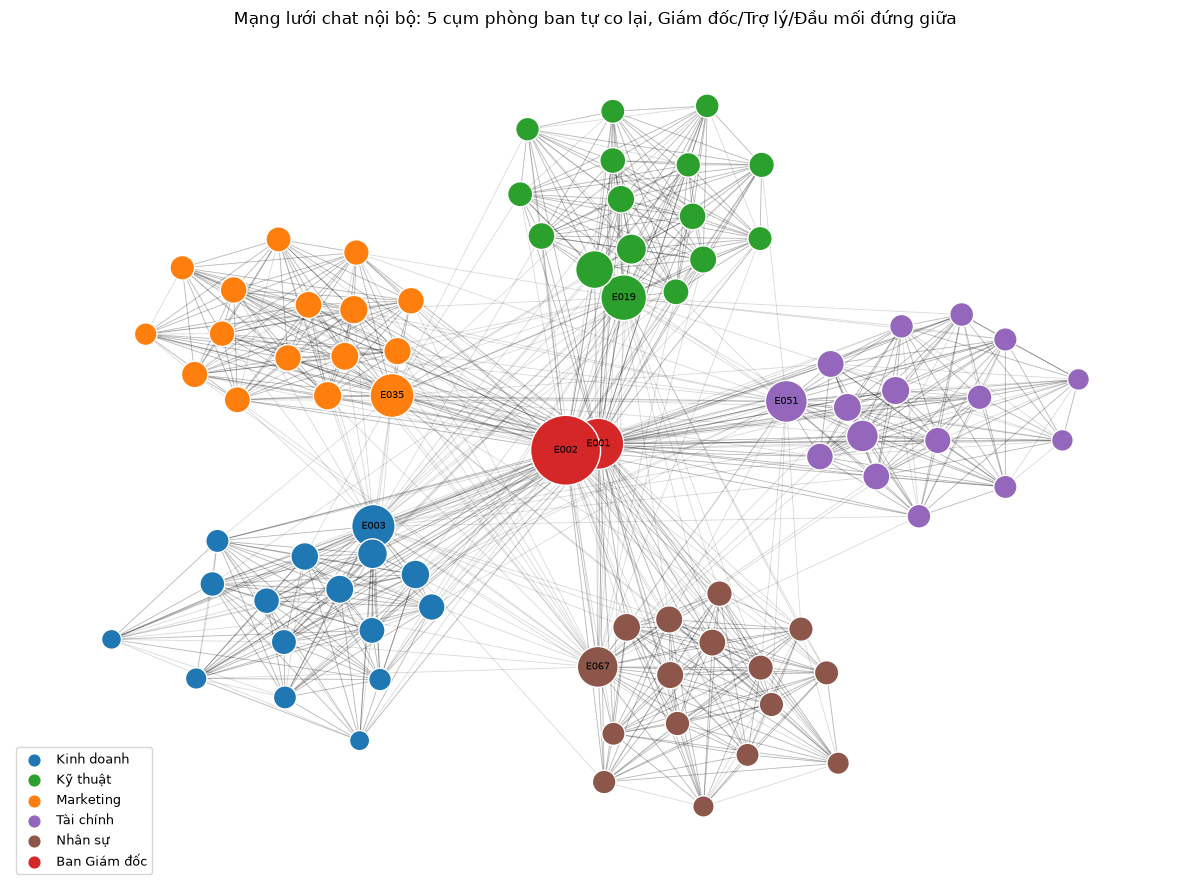

Đã lưu ..\data\processed\graph_mang_luoi.png


In [6]:
khoi_luong = dict(G.degree(weight="so_tin"))          # tổng tin gửi + nhận
mau_pb = {"Kinh doanh": "#1f77b4", "Kỹ thuật": "#2ca02c", "Marketing": "#ff7f0e",
          "Tài chính": "#9467bd", "Nhân sự": "#8c564b", "Ban Giám đốc": "#d62728"}

vi_tri = nx.spring_layout(G, seed=42, k=0.35, weight="so_tin")
canh_dam = [(u, v) for u, v, d in G.edges(data=True) if d["so_tin"] >= 3]

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(G, vi_tri, edgelist=canh_dam, alpha=0.15,
                       arrows=False, width=0.6, ax=ax)
nx.draw_networkx_nodes(G, vi_tri, ax=ax,
    node_color=[mau_pb[G.nodes[n]["phong_ban"]] for n in G],
    node_size=[20 + khoi_luong[n] * 1.1 for n in G], edgecolors="white")
nx.draw_networkx_labels(G, vi_tri, ax=ax, font_size=7,
    labels={n: n for n in ["E001", "E002", *dau_moi.values()]})

for pb, mau in mau_pb.items():
    ax.scatter([], [], c=mau, label=pb, s=60)
ax.legend(loc="lower left", fontsize=9)
ax.set_title("Mạng lưới chat nội bộ: 5 cụm phòng ban tự co lại, Giám đốc/Trợ lý/Đầu mối đứng giữa")
ax.axis("off")
plt.tight_layout()
fig.savefig(PROCESSED / "graph_mang_luoi.png", bbox_inches="tight")
plt.show()
print("Đã lưu", PROCESSED / "graph_mang_luoi.png")

## 15.3. Centrality — "quan trọng" có ít nhất ba nghĩa khác nhau

| Chỉ số | Đo gì | Câu hỏi nghiệp vụ | Người "cao điểm" trong công ty |
|:---|:---|:---|:---|
| **Degree** | số kết nối (có trọng số: số tin) | ai giao tiếp NHIỀU nhất? | tổng đài, người nổi tiếng |
| **Betweenness** | nằm trên bao nhiêu đường đi ngắn nhất giữa các cặp | ai là CẦU NỐI — rút ra là mạng đứt? | đầu mối liên phòng |
| **Closeness** | trung bình gần mọi người đến đâu | tin từ ai LAN NHANH nhất? | người ở "trung tâm địa lý" của mạng |

Ba bảng xếp hạng dưới đây cho ba danh sách KHÁC NHAU — đó chính là bài học.

In [7]:
do_in = dict(G.in_degree(weight="so_tin"))
do_out = dict(G.out_degree(weight="so_tin"))
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)

bang_ct = pd.DataFrame({
    "phong_ban": pd.Series(phong_cua),
    "tin_nhan_duoc": pd.Series(do_in), "tin_gui_di": pd.Series(do_out),
    "betweenness": pd.Series(betweenness).round(4),
    "closeness": pd.Series(closeness).round(3),
})
for chi_so in ["tin_nhan_duoc", "betweenness", "closeness"]:
    print(f"=== Top 5 theo {chi_so} ===")
    print(bang_ct.nlargest(5, chi_so)[["phong_ban", chi_so]].to_string(), "\n")

=== Top 5 theo tin_nhan_duoc ===
         phong_ban  tin_nhan_duoc
E002  Ban Giám đốc           1918
E001  Ban Giám đốc            818
E019      Kỹ thuật            681
E035     Marketing            678
E051     Tài chính            650 

=== Top 5 theo betweenness ===
         phong_ban  betweenness
E001  Ban Giám đốc       0.2793
E002  Ban Giám đốc       0.2450
E003    Kinh doanh       0.0465
E067       Nhân sự       0.0453
E019      Kỹ thuật       0.0435 

=== Top 5 theo closeness ===
         phong_ban  closeness
E001  Ban Giám đốc       1.00
E002  Ban Giám đốc       1.00
E003    Kinh doanh       0.91
E019      Kỹ thuật       0.91
E035     Marketing       0.88 



**Đọc kết quả:** Giám đốc/Trợ lý đứng đầu về lượng tin (Degree); các **Đầu mối** vươn lên ở Betweenness dù lượng tin ít hơn hẳn — họ không nói nhiều, nhưng **mọi con đường liên phòng đều đi qua họ**. Nếu một Đầu mối nghỉ việc, hai phòng gần như mất liên lạc — Betweenness chính là chỉ số "rủi ro đứt gãy tổ chức" mà không bảng lương nào cho thấy.

## 15.4. PageRank — uy tín lan truyền (deliverable 2)

**Trực giác:** một người quan trọng không phải vì NHẬN nhiều tin, mà vì nhận tin **từ những người quan trọng**. PageRank (thuật toán xếp hạng web của Google) lan "uy tín" qua các cạnh: mỗi vòng, uy tín của bạn chia đều cho những người bạn nhắn tới; hệ số hãm α = 0.85 mô phỏng xác suất "nhảy ngẫu nhiên". Đây là **định nghĩa đệ quy** — đúng loại câu hỏi mà SQL bó tay còn đồ thị giải trong một dòng.

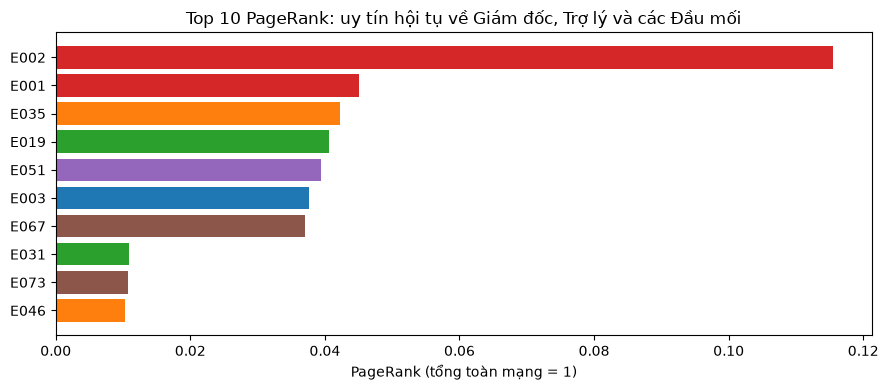

Người được PageRank 'thăng hạng' mạnh nhất so với đếm tin thô:
      phong_ban  tin_nhan_duoc  hang_theo_tin  hang_pagerank
E057  Tài chính            113             53             11
E065  Tài chính            103             71             39
E072    Nhân sự            104             70             38

Đã lưu ..\data\processed\pagerank_nhan_vien.csv


In [8]:
pagerank = nx.pagerank(G, alpha=0.85, weight="so_tin")
bang_ct["pagerank"] = pd.Series(pagerank).round(5)

top10 = bang_ct.nlargest(10, "pagerank")
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top10.index[::-1], top10["pagerank"][::-1],
        color=[mau_pb[p] for p in top10["phong_ban"][::-1]])
ax.set_title("Top 10 PageRank: uy tín hội tụ về Giám đốc, Trợ lý và các Đầu mối")
ax.set_xlabel("PageRank (tổng toàn mạng = 1)")
plt.tight_layout(); plt.show()

# So sánh hai cách xếp hạng: đếm tin (in-degree) vs uy tín (PageRank)
bang_ct["hang_theo_tin"] = bang_ct["tin_nhan_duoc"].rank(ascending=False).astype(int)
bang_ct["hang_pagerank"] = bang_ct["pagerank"].rank(ascending=False).astype(int)
lech = (bang_ct["hang_theo_tin"] - bang_ct["hang_pagerank"]).sort_values(ascending=False)
print("Người được PageRank 'thăng hạng' mạnh nhất so với đếm tin thô:")
print(bang_ct.loc[lech.index[:3], ["phong_ban", "tin_nhan_duoc",
                                   "hang_theo_tin", "hang_pagerank"]].to_string())

bang_ct.sort_values("pagerank", ascending=False).to_csv(
    PROCESSED / "pagerank_nhan_vien.csv", encoding="utf-8-sig")
print("\nĐã lưu", PROCESSED / "pagerank_nhan_vien.csv")

## 15.5. Phát hiện cộng đồng — tổ chức "thật" nhìn từ hành vi

Thuật toán **Louvain** gom đỉnh thành cụm sao cho tin nhắn nội cụm dày đặc, liên cụm thưa thớt — **không hề biết cột phòng ban**. Nếu cụm tìm được trùng với phòng ban thật, nghĩa là sơ đồ tổ chức trên giấy khớp với tổ chức trong hành vi (và ngược lại — lệch ở đâu, chỗ đó đáng để HR nhìn vào):

In [9]:
cong_dong = nx.community.louvain_communities(G.to_undirected(), weight="so_tin", seed=42)
print(f"Louvain tìm thấy {len(cong_dong)} cộng đồng (không hề biết phòng ban):\n")
for i, cum in enumerate(sorted(cong_dong, key=len, reverse=True)):
    pb_trong_cum = pd.Series([phong_cua[n] for n in cum]).value_counts()
    print(f"  Cộng đồng {i + 1} ({len(cum):>2} người): "
          f"{pb_trong_cum.idxmax():<12} chiếm {pb_trong_cum.max() / len(cum):.0%}"
          f"   {dict((k, int(v)) for k, v in pb_trong_cum.items())}")

Louvain tìm thấy 5 cộng đồng (không hề biết phòng ban):

  Cộng đồng 1 (17 người): Kỹ thuật     chiếm 94%   {'Kỹ thuật': 16, 'Ban Giám đốc': 1}
  Cộng đồng 2 (17 người): Tài chính    chiếm 94%   {'Tài chính': 16, 'Ban Giám đốc': 1}
  Cộng đồng 3 (16 người): Kinh doanh   chiếm 100%   {'Kinh doanh': 16}
  Cộng đồng 4 (16 người): Marketing    chiếm 100%   {'Marketing': 16}
  Cộng đồng 5 (16 người): Nhân sự      chiếm 100%   {'Nhân sự': 16}


---
## 15.6. Neo4j + Cypher — đồ thị trong cơ sở dữ liệu chuyên dụng

NetworkX phân tích trong RAM một máy; **Neo4j** là CSDL đồ thị: dữ liệu sống lâu dài, nhiều người truy vấn, có ngôn ngữ riêng — **Cypher**, "SQL của đồ thị", viết mẫu hình bằng ký tự ASCII:

```
(a:NhanVien)-[r:NHAN_TIN]->(b:NhanVien)
 ▲ đỉnh, nhãn     ▲ cạnh, loại      ▲ đỉnh
```

| SQL | Cypher |
|:---|:---|
| `SELECT ... FROM ... JOIN` | `MATCH (mẫu hình) RETURN ...` |
| `WHERE` | `WHERE` (y hệt) |
| `GROUP BY` + hàm gộp | gộp tự động khi RETURN có hàm gộp |
| JOIN đệ quy nhiều tầng | `-[*]-` (đường đi độ dài bất kỳ) — một ký hiệu |

Bật Neo4j (dịch vụ có sẵn trong `docker-compose.yml` của khóa học, kèm plugin **Graph Data Science**):

In [10]:
import subprocess, time
GOC = Path("..").resolve()
subprocess.run(["docker", "compose", "up", "-d", "neo4j"], cwd=GOC, check=True,
               capture_output=True)

from neo4j import GraphDatabase
driver = None
for _ in range(30):
    try:
        driver = GraphDatabase.driver("bolt://localhost:7687",
                                      auth=("neo4j", "BigDataPass123"))
        with driver.session() as s:
            s.run("RETURN 1").single()
        break
    except Exception:
        time.sleep(5)
if driver is None:
    raise RuntimeError("Neo4j chưa sẵn sàng — kiểm tra: docker compose logs neo4j")
with driver.session() as s:
    print("Neo4j sẵn sàng | GDS", s.run("RETURN gds.version()").single()[0])
print("Neo4j Browser: http://localhost:7474  (đăng nhập neo4j / BigDataPass123)")

CalledProcessError: Command '['docker', 'compose', 'up', '-d', 'neo4j']' returned non-zero exit status 1.

In [ ]:
# --- Nạp đồ thị vào Neo4j: 82 đỉnh NhanVien + các cạnh NHAN_TIN ---
with driver.session() as s:
    s.run("MATCH (n:NhanVien) DETACH DELETE n")            # dọn dữ liệu cũ của bài
    s.run("CREATE CONSTRAINT nhan_vien_id IF NOT EXISTS "
          "FOR (n:NhanVien) REQUIRE n.id IS UNIQUE")
    s.run("""UNWIND $rows AS r
              MERGE (n:NhanVien {id: r.id})
              SET n.phong_ban = r.phong_ban, n.vai_tro = r.vai_tro""",
          rows=nv.to_dict("records"))
    s.run("""UNWIND $rows AS r
              MATCH (a:NhanVien {id: r.sender}), (b:NhanVien {id: r.receiver})
              MERGE (a)-[l:NHAN_TIN]->(b)
              SET l.so_tin = r.so_tin""",
          rows=canh.to_dict("records"))
    kq = s.run("""MATCH (n:NhanVien)
                  OPTIONAL MATCH ()-[l:NHAN_TIN]->()
                  RETURN count(DISTINCT n) AS dinh, count(DISTINCT l) AS canh""").single()
print(f"Đã nạp vào Neo4j: {kq['dinh']} đỉnh, {kq['canh']:,} cạnh")

Đã nạp vào Neo4j: 82 đỉnh, 1,783 cạnh


Ba câu Cypher tiêu biểu — chú ý mỗi câu là **một mẫu hình vẽ bằng ký tự**, không có JOIN nào:

In [ ]:
cau_lenh = {
"① Top 5 người nhận nhiều tin nhất":
"""MATCH (:NhanVien)-[l:NHAN_TIN]->(n:NhanVien)
RETURN n.id AS id, n.phong_ban AS phong_ban, sum(l.so_tin) AS tin_nhan_duoc
ORDER BY tin_nhan_duoc DESC LIMIT 5""",

"② Đường liên lạc ngắn nhất giữa hai nhân viên khác phòng":
"""MATCH p = shortestPath(
      (a:NhanVien {id:'E010'})-[:NHAN_TIN*..6]-(b:NhanVien {id:'E060'}))
RETURN [n IN nodes(p) | n.id + ' (' + n.phong_ban + ')'] AS duong_di""",

"③ Ai bắc cầu tới nhiều phòng ban khác nhất":
"""MATCH (a:NhanVien)-[:NHAN_TIN]->(b:NhanVien)
WHERE a.phong_ban <> b.phong_ban
RETURN a.id AS id, a.vai_tro AS vai_tro,
       count(DISTINCT b.phong_ban) AS so_phong_khac
ORDER BY so_phong_khac DESC LIMIT 5""",
}
with driver.session() as s:
    for ten, q in cau_lenh.items():
        print(ten)
        print(pd.DataFrame([dict(r) for r in s.run(q)]).to_string(index=False), "\n")

① Top 5 người nhận nhiều tin nhất
  id    phong_ban  tin_nhan_duoc
E002 Ban Giám đốc           1918
E001 Ban Giám đốc            818
E019     Kỹ thuật            681
E035    Marketing            678
E051    Tài chính            650 

② Đường liên lạc ngắn nhất giữa hai nhân viên khác phòng
                                              duong_di
[E010 (Kinh doanh), E019 (Kỹ thuật), E060 (Tài chính)] 

③ Ai bắc cầu tới nhiều phòng ban khác nhất
  id   vai_tro  so_phong_khac
E077 Nhân viên              5
E076 Nhân viên              5
E052 Nhân viên              5
E040 Nhân viên              5
E007 Nhân viên              5 



**PageRank ngay trong Neo4j** bằng thư viện Graph Data Science (GDS): chiếu đồ thị vào bộ nhớ ➔ chạy thuật toán ➔ đối chiếu với NetworkX. Cùng thuật toán, hai công cụ — bảng xếp hạng phải trùng nhau:

In [ ]:
with driver.session() as s:
    s.run("CALL gds.graph.drop('chat', false)")
    s.run("""CALL gds.graph.project('chat', 'NhanVien',
              {NHAN_TIN: {properties: 'so_tin'}})""")
    kq = s.run("""CALL gds.pageRank.stream('chat',
                    {relationshipWeightProperty: 'so_tin', dampingFactor: 0.85})
                  YIELD nodeId, score
                  RETURN gds.util.asNode(nodeId).id AS id, score
                  ORDER BY score DESC LIMIT 10""")
    pr_neo4j = pd.DataFrame([dict(r) for r in kq]).set_index("id")

so_sanh = pr_neo4j.join(bang_ct[["phong_ban", "pagerank"]])
so_sanh.columns = ["PageRank_Neo4j", "phong_ban", "PageRank_NetworkX"]
print(so_sanh[["phong_ban", "PageRank_Neo4j", "PageRank_NetworkX"]].round(4).to_string())
print("\nHai cột điểm khác thang đo (GDS không chuẩn hóa tổng = 1) nhưng THỨ HẠNG trùng nhau —")
print("thuật toán là một, công cụ chỉ là cái vỏ.")
driver.close()

Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)", position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'column': 1, 'offset': 0, 'line': 1}}> for query: "CALL gds.graph.drop('chat', false)"


         phong_ban  PageRank_Neo4j  PageRank_NetworkX
id                                                   
E002  Ban Giám đốc          9.0441             0.1155
E001  Ban Giám đốc          3.5425             0.0451
E035     Marketing          3.3039             0.0422
E019      Kỹ thuật          3.1789             0.0406
E051     Tài chính          3.0902             0.0394
E003    Kinh doanh          2.9570             0.0377
E067       Nhân sự          2.9056             0.0370
E031      Kỹ thuật          0.8609             0.0109
E073       Nhân sự          0.8455             0.0107
E046     Marketing          0.8065             0.0102

Hai cột điểm khác thang đo (GDS không chuẩn hóa tổng = 1) nhưng THỨ HẠNG trùng nhau —
thuật toán là một, công cụ chỉ là cái vỏ.


> **Tự khám phá thêm:** mở **Neo4j Browser** tại http://localhost:7474, đăng nhập `neo4j / BigDataPass123`, chạy
> `MATCH p = (:NhanVien)-[:NHAN_TIN]->(:NhanVien) RETURN p LIMIT 150`
> để xem đồ thị tương tác — kéo thả đỉnh, click xem thuộc tính. Học xong tắt cụm bằng `docker compose stop neo4j`.

---
## TỔNG KẾT BUỔI 15

| Câu hỏi | Công cụ | Kết quả |
|:---|:---|:---|
| Bảng ➔ đồ thị? | groupby + `from_pandas_edgelist` | 82 đỉnh, ~2.400 cạnh có trọng số |
| Ai giao tiếp nhiều nhất? | Degree | Giám đốc, Trợ lý |
| Ai là cầu nối rủi ro? | Betweenness | các Đầu mối liên phòng |
| Ai uy tín nhất? | PageRank (NetworkX + Neo4j GDS) | hội tụ về cùng một bảng xếp hạng |
| Tổ chức thật giống sơ đồ? | Louvain | tìm lại đúng các phòng ban từ hành vi |
| Truy vấn quan hệ sâu? | Cypher | shortestPath, mẫu hình liên phòng — không một JOIN |

---
# BÀI TẬP VỀ NHÀ

#### Bài tập 1 (NetworkX): Lọc riêng đồ thị con của phòng "Kỹ thuật" (`G.subgraph`), tính lại degree và PageRank nội bộ. Người đứng đầu nội bộ có trùng với Đầu mối của phòng không? Nhận xét 2–3 câu.

In [ ]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Cypher): Viết truy vấn tìm **các cặp nhắn tin hai chiều** (A➔B và B➔A đều tồn tại) có tổng số tin lớn nhất — gợi ý: `MATCH (a)-[l1:NHAN_TIN]->(b)-[l2:NHAN_TIN]->(a) WHERE a.id < b.id`. Cặp "thân nhau nhất" công ty là ai?

In [ ]:
# --- BÀI TẬP 2 ---


#### Bài tập 3 (GDS): Chạy thuật toán cộng đồng ngay trong Neo4j: `CALL gds.louvain.stream('chat', {relationshipWeightProperty: 'so_tin'})`. Số cộng đồng và thành phần có khớp với kết quả NetworkX ở mục 15.5 không?

In [ ]:
# --- BÀI TẬP 3 ---
